In [1]:
# input
rep_info_file = "../../data/repId-numPro-numPredPro-numResi-numPredResi-numAnnoPro-isAnno.tsv"
# output
pro_consis_fig = "./fig/pro_consistency_pie.pdf"
resi_consis_fig = "./fig/resi_consistency_on_pro_consistency_100_pie.pdf"

In [2]:
import pandas as pd

df = pd.read_table(rep_info_file, header=None, names=["rep_id", "num_protein", "num_pred_protein", "num_residue", "num_pred_residue", "num_anno_pro", "is_anno"])
df_rep = df[df.apply(lambda row: row['num_pred_protein'] == row['num_protein'], axis=1)]

[6794066, 621768]
[0.9161566993004429, 0.08384330069955719]


<Figure size 240x240 with 0 Axes>

([<matplotlib.patches.Wedge at 0x7020ade61e90>,
 [Text(1.0620609703218333, -0.28640268036288724, ''),
  Text(-1.0620610636436154, 0.286402334299482, '')],
 [Text(0.579305983811909, -0.15621964383430212, '91.6%'),
  Text(-0.5793060347146993, 0.1562194550724447, '8.4%')])

Text(0.5, -0.1, 'Total number of clusters = 7415834')

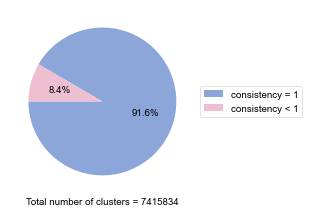

In [3]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

y = [len(df_rep), len(df) - len(df_rep)]
print(y)
y = [i / sum(y) for i in y]
print(y)
plt.figure(figsize=(2.4, 2.4))
plt.pie(y, autopct="%.1f%%", startangle=180)
plt.legend(
    labels=[
            'consistency = 1',
            'consistency < 1'],
    loc='center left',
    bbox_to_anchor=(1,.5)
)
plt.title(
    f"Total number of clusters = {len(df)}",
    loc="center",
    y=-0.1,
)

plt.savefig(pro_consis_fig, bbox_inches="tight", transparent=True)

[6142107, 651959]


<Figure size 240x240 with 0 Axes>

([<matplotlib.patches.Wedge at 0x7020ad787510>,
 [Text(1.0503918910906003, -0.3266142604527742, ''),
  Text(-1.050391841773207, 0.3266144190575334, '')],
 [Text(0.5729410315039637, -0.17815323297424043, '90.4%'),
  Text(-0.5729410046035674, 0.1781533194859273, '9.6%')])

Text(0.5, -0.1, 'Total number of clusters = 6794066')

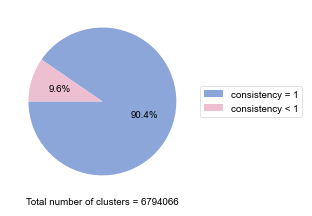

In [4]:
resi_ratio_100 = len(df_rep[df_rep.apply(lambda row: row['num_pred_residue'] == row['num_residue'], axis=1)])

y = [resi_ratio_100, len(df_rep) - resi_ratio_100]
print(y)
y = [i / sum(y) for i in y]
plt.figure(figsize=(2.4, 2.4))
plt.pie(y, autopct="%.1f%%", startangle=180)
plt.legend(
    labels=[
            'consistency = 1',
            'consistency < 1'],
    loc='center left',
    bbox_to_anchor=(1,.5)
)
plt.title(
    f"Total number of clusters = {len(df_rep)}",
    loc="center",
    y=-0.1,
)

plt.savefig(resi_consis_fig, bbox_inches="tight", transparent=True)